<a href="https://colab.research.google.com/github/abood-W/Fine-Tuning/blob/main/fineTunning_a_model_using_XLNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install cleantext
!pip install evaluate
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer ,XLNetForSequenceClassification,TrainingArguments,Trainer,pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import evaluate
import random

In [4]:
data_train = pd.read_csv('/content/emotion-labels-train.csv')
data_test = pd.read_csv('/content/emotion-labels-test.csv')
data_val = pd.read_csv('/content/emotion-labels-val.csv')

In [47]:
data_train['label'].unique()

array(['joy', 'fear', 'anger', 'sadness'], dtype=object)

In [5]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [6]:
data = pd.concat([data_train,data_test],ignore_index=True)

In [7]:
data['text_clean']=data['text'].apply(lambda x : clean(x))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
data['text_clean']=data['text_clean'].apply(lambda x : re.sub('@[^\s]+', '', x))

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9809/3395127084.py:1: SyntaxWarning: invalid escape sequence '\s'
  data['text_clean']=data['text_clean'].apply(lambda x : re.sub('@[^\s]+', '', x))


### Remove Emojis
Now, let's remove any remaining emojis from the `text_clean` column using a regular expression.

In [9]:
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["  # Start character class
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"  # Dingbats
        "\U000024C2-\U0001F251"  # Enclosed CJK Letters and Months
        "]+"
    )
    return emoji_pattern.sub(r'', text)

data['text_clean'] = data['text_clean'].apply(remove_emojis)

In [10]:
def clean_text_further(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['text_clean'] = data['text_clean'].apply(clean_text_further)

In [11]:
display(data.head())

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,got back see garydelaney burslem amaz face sti...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear even absolut hilar dont think laugh mu...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,wait week game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,gardinerlov thank much gloria your sweet thoug...
4,I feel so blessed to work with the family that...,joy,feel bless work famili nanni noth love amp app...


<Axes: xlabel='label'>

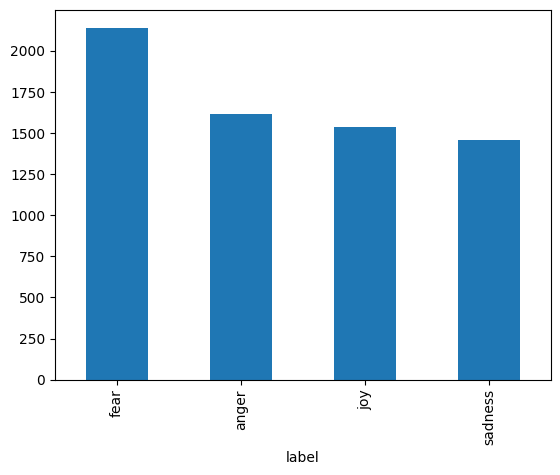

In [12]:
data['label'].value_counts().plot(kind='bar')

In [13]:
g=data.groupby('label')
data=pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))

/tmp/ipykernel_9809/3191498142.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data=pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))


<Axes: xlabel='label'>

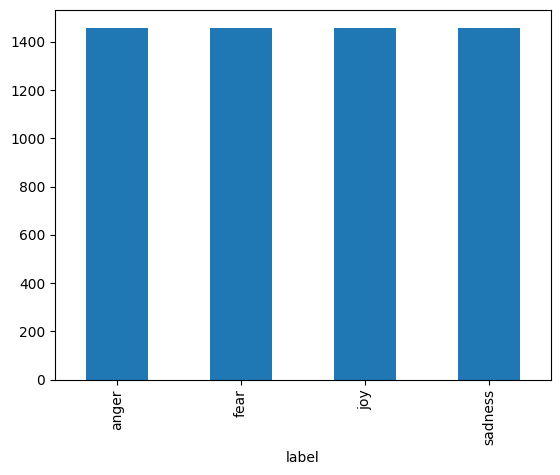

In [14]:
data['label'].value_counts().plot(kind='bar')

In [15]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])


In [16]:
NUM_LABELS = 4

In [17]:
train_split , test_split = train_test_split(data,train_size=0.8)
train_split ,val_split = train_test_split(train_split,train_size=0.9)

In [18]:
print(len(train_split))
print(len(val_split))
print(len(test_split))

4201
467
1168


In [19]:
train_df = pd.DataFrame({
    "label":train_split.label_int.values,
    "text":train_split.text_clean.values
})

test_df = pd.DataFrame({
    "label":test_split.label_int.values,
    "text":test_split.text_clean.values
})

In [20]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [21]:
datasets_dict = datasets.DatasetDict({"train":train_df,"test":test_df})

In [22]:
datasets_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4201
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1168
    })
})

In [24]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

In [25]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True,max_length=128)

In [26]:
tokenized_datasets = datasets_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/4201 [00:00<?, ? examples/s]

Map:   0%|          | 0/1168 [00:00<?, ? examples/s]

In [27]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4201
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1168
    })
})

In [28]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 17, 29816, 3298, 1550, 17, 31297, 9570, 2517, 1141, 153, 17, 1315, 722, 267, 5694, 1426, 248, 17, 9977, 556, 420, 23580, 220, 46, 1747, 7580, 1258, 4, 3]


In [29]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))

In [30]:
model = XLNetForSequenceClassification.from_pretrained(
    "xlnet-base-cased",
    num_labels=NUM_LABELS ,
    id2label={0: "anger", 1: "fear", 2: "joy", 3: "sadness"},
    label2id={"anger": 0, "fear": 1, "joy": 2, "sadness": 3},
)


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
metric = evaluate.load("accuracy")

In [32]:
def comput_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [33]:
training_arg = TrainingArguments(output_dir="test_trainer",eval_strategy="epoch",num_train_epochs=3)

In [34]:
trainer = Trainer(
    model=model,
    args=training_arg,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=comput_metrics,
)

In [35]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.324936,0.410000
2,No log,1.323476,0.410000
3,No log,1.321896,0.410000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=39, training_loss=1.3754881834372497, metrics={'train_runtime': 728.2234, 'train_samples_per_second': 0.412, 'train_steps_per_second': 0.054, 'total_flos': 21366375321600.0, 'train_loss': 1.3754881834372497, 'epoch': 3.0})

In [36]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
No log,1.321896,3,0.410000


{'eval_loss': 1.3218960762023926, 'eval_accuracy': 0.41}

In [37]:
model.save_pretrained('fine_tuned_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [38]:
fine_tuned_moel = XLNetForSequenceClassification.from_pretrained('fine_tuned_model')

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

In [39]:
clf = pipeline("text-classification" ,fine_tuned_moel,tokenizer=tokenizer)

In [42]:
rand_int=random.randint(0,len(val_split)-1)
print(val_split['text_clean'].iloc[rand_int])
answer=clf(val_split['text_clean'].iloc[rand_int])
print(answer)

aamnaa drkarthikn per capita incom almost like us gini coeffici dismal ambit high output zero
[{'label': 'sadness', 'score': 0.38022828102111816}]
